Домашняя контрольная работа 1

Задание: Реализовать алгоритм поиска и сопоставления ключевых точек.

Пункт 1

Получить два изображения одного и того же объекта с разных ракурсов 
(радиальное смещение камеры при смене ракурса 5–10 градусов в 
горизонтальной плоскости). По возможности использовать 
широкоугольный объектив, содержащий бочкообразную дисторсию. 

In [3]:
#Подключение библиотек
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [4]:
#Отдельная функция для отображение изображения (OpenCV BRG в Matplotlib RGB)
def show(img, title=None, ax=None, cmap=None):
    if ax is None:
        plt.figure(figsize=(6,4))
        ax = plt.gca()
    # Если 3 канала - переворачиваем из BGR -> RGB для plt
    if img is None:
        return
    if len(img.shape)==3 and img.shape[2]==3:
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        ax.imshow(img, cmap=cmap)
    ax.axis('off')
    if title:
        ax.set_title(title)

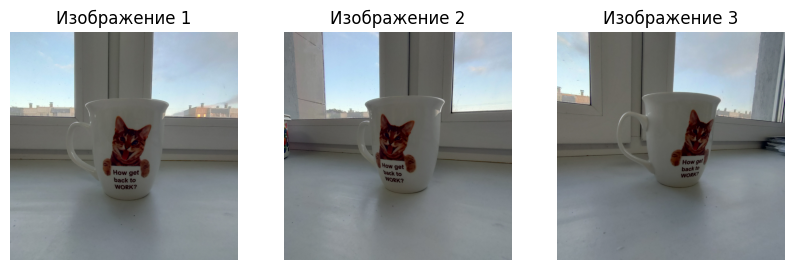

In [5]:
# Подключение изображений
img_1_path = r"D:\Programming-at-SUSU\BasicOfCV\Homeworks\KR_1\photos\1_sun.jpg"
img_2_path = r"D:\Programming-at-SUSU\BasicOfCV\Homeworks\KR_1\photos\2_sun.jpg"
img_3_path = r"D:\Programming-at-SUSU\BasicOfCV\Homeworks\KR_1\photos\3_sun.jpg"

img1 = cv2.imread(img_1_path)
img2 = cv2.imread(img_2_path)
img3 = cv2.imread(img_3_path)

#Отображение
plt.figure(figsize=(10,4))
ax1 = plt.subplot(1,3,1)
show(img1, "Изображение 1", ax=ax1)
ax2 = plt.subplot(1,3,2)
show(img2, "Изображение 2", ax=ax2)
ax3 = plt.subplot(1,3,3)
show(img3, "Изображение 3", ax=ax3)

Пункт 2

Провести шумоподавление 3 различными фильтрами 

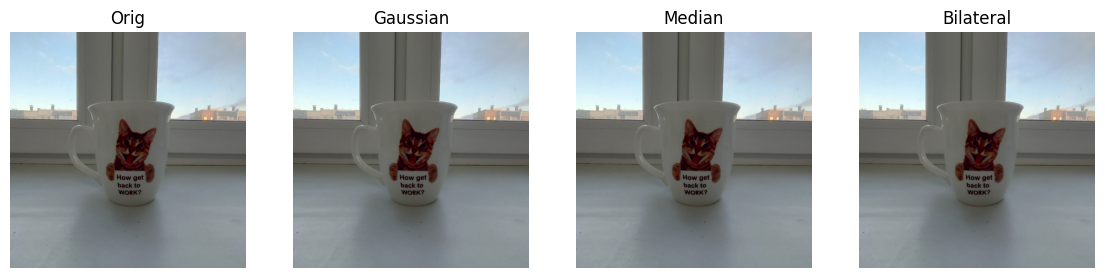

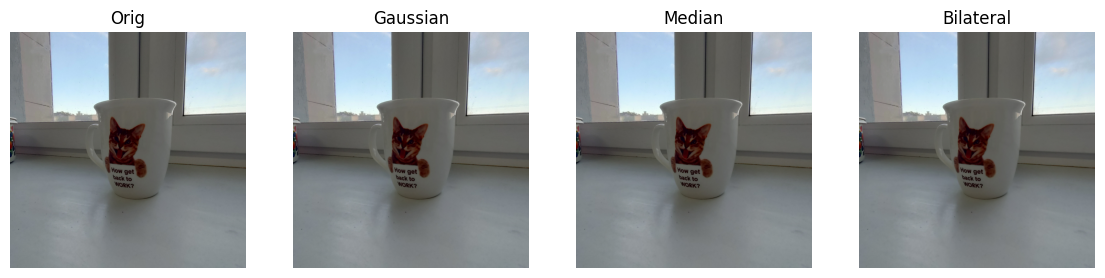

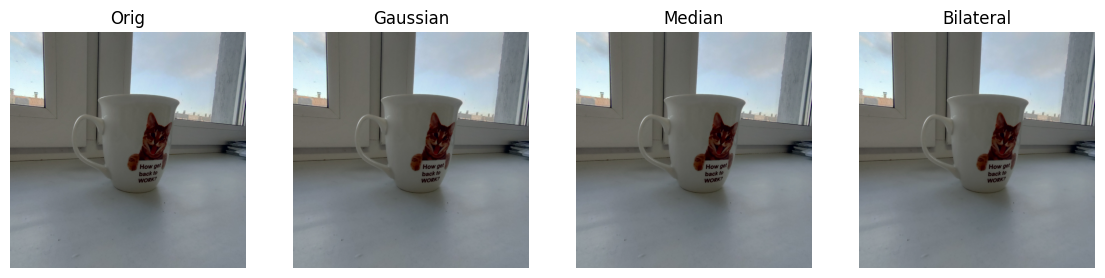

In [6]:
"""
Добавим 3 шумоподавления:
    Медианный - medainBlur
    Гауссовский - GaussianBlur
    Билатеральный фильтра - bilateralFilter
"""

#Применение медианного фильтра
M_img1 = cv2.medianBlur(img1, ksize=5)
M_img2 = cv2.medianBlur(img2, 5)
M_img3 = cv2.medianBlur(img3, 5)

G_img1 = cv2.GaussianBlur(img1, ksize=(5,5), sigmaX=1.5) 
G_img2 = cv2.GaussianBlur(img2, (5,5), 1.5)
G_img3 = cv2.GaussianBlur(img3, (5,5), 1.5)

B_img1 = cv2.bilateralFilter(img1, d=9, sigmaColor=75, sigmaSpace=75)
B_img2 = cv2.bilateralFilter(img2, 9, 75, 75)
B_img3 = cv2.bilateralFilter(img3, 9, 75, 75)

plt.figure(figsize=(14,8))
axs = [plt.subplot(1,4,i+1) for i in range(4)]
show(img1, "Orig", ax=axs[0])
show(G_img1, "Gaussian", ax=axs[1])
show(M_img1, "Median", ax=axs[2])
show(B_img1, "Bilateral", ax=axs[3])

plt.figure(figsize=(14,8))
axs = [plt.subplot(1,4,i+1) for i in range(4)]
show(img2, "Orig", ax=axs[0])
show(G_img2, "Gaussian", ax=axs[1])
show(M_img2, "Median", ax=axs[2])
show(B_img2, "Bilateral", ax=axs[3])

plt.figure(figsize=(14,8))
axs = [plt.subplot(1,4,i+1) for i in range(4)]
show(img3, "Orig", ax=axs[0])
show(G_img3, "Gaussian", ax=axs[1])
show(M_img3, "Median", ax=axs[2])
show(B_img3, "Bilateral", ax=axs[3])
plt.show()

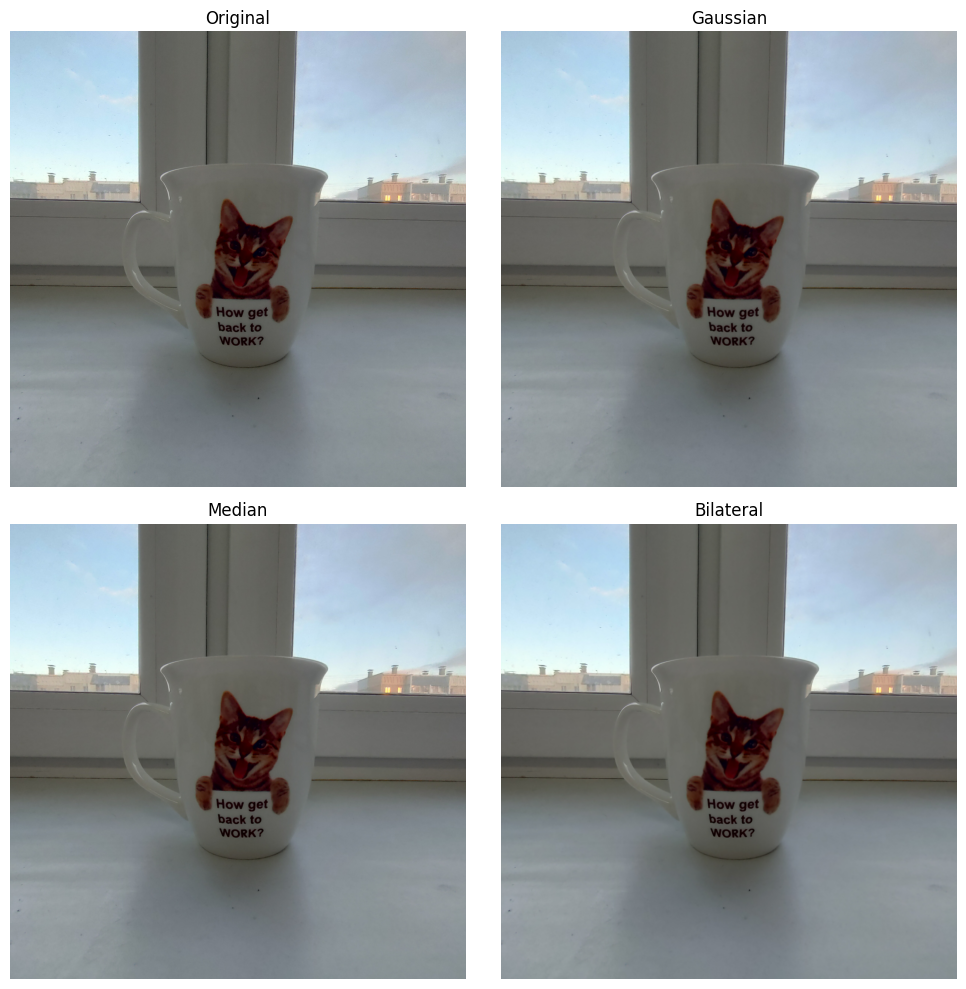

In [7]:
#Тестовая выборка картинок, чтобы увидеть разницу в шумоподавлении

Mtest_img1 = cv2.medianBlur(img1, ksize=11)
Gtest_img1 = cv2.GaussianBlur(img1, ksize=(3,3), sigmaX=5) 
Btest_img1 = cv2.bilateralFilter(img1, d=3, sigmaColor=20, sigmaSpace=40)

fig = plt.figure(figsize=(10,10))

ax1 = fig.add_subplot(2,2,1)
show(img1, "Original", ax=ax1)

ax2 = fig.add_subplot(2,2,2)
show(G_img1, "Gaussian", ax=ax2)

ax3 = fig.add_subplot(2,2,3)
show(M_img1, "Median", ax=ax3)

ax4 = fig.add_subplot(2,2,4)
show(B_img1, "Bilateral", ax=ax4)

plt.tight_layout()
plt.show()

Пункт 3

Провести коррекцию гистограммы 

In [8]:
"""
Используем формат YCrBr вместо RGB
Используем функции equalizeHist и createCLAHE
"""
def equalize_hist_color(img):
    # преобразуем в YCrCb и выровняем Y
    ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
    ycrcb[:,:,0] = cv2.equalizeHist(ycrcb[:,:,0])
    return cv2.cvtColor(ycrcb, cv2.COLOR_YCrCb2BGR)

def clahe_color(img, clipLimit=2.0, tileGridSize=(8,8)):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    clahe = cv2.createCLAHE(clipLimit=clipLimit, tileGridSize=tileGridSize)
    lab[:,:,0] = clahe.apply(lab[:,:,0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

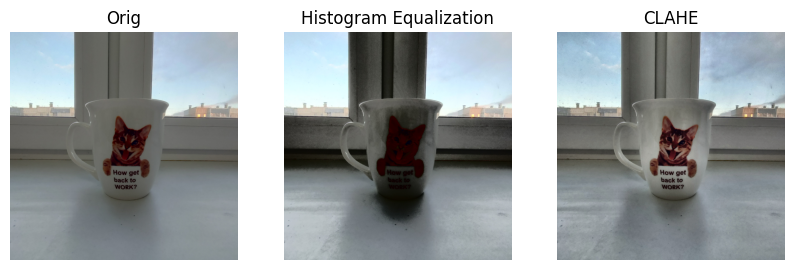

In [9]:
eq_img1 = equalize_hist_color(img1)
clahe_img1 = clahe_color(img1)

plt.figure(figsize=(10,4))
ax = plt.subplot(1,3,1); show(img1, "Orig", ax=ax)
ax = plt.subplot(1,3,2); show(eq_img1, "Histogram Equalization", ax=ax)
ax = plt.subplot(1,3,3); show(clahe_img1, "CLAHE", ax=ax)
plt.show()

Пункт 4

Провести гамма-коррекцию

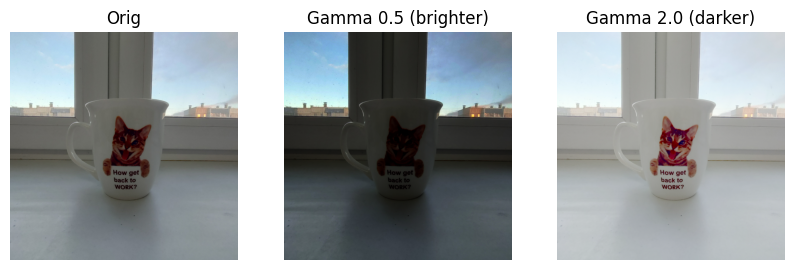

In [ ]:
# Отдельная функция для гамма-коррекции
def gamma_correction(img, gamma=1.0):
    invGamma = 1.0 / gamma
    table = np.array([((i/255.0) ** invGamma) * 255 for i in np.arange(256)]).astype("uint8")
    return cv2.LUT(img, table)

g05 = gamma_correction(img1, 0.5)  # brighten
g2  = gamma_correction(img1, 2.0)  # darken

plt.figure(figsize=(10,4))
axs = [plt.subplot(1,3,i+1) for i in range(3)]
show(img1, "Оригинал", ax=axs[0])
show(g05, "Г-Коррекция λ = 0.5 (brighter)", ax=axs[1])
show(g2, "Г-Коррекция λ = 2.0 (darker)", ax=axs[2])
plt.show()

Пункт 5

1. Провести коррекцию геометрических искажений:
  
   a. Провести калибровку камеры, с которой получены изображения с помощью встроенных функций библиотеки OpenCV.
  
   b. Получить матрицу камеры и коэффициенты дисторсии.
  
   c. Провести коррекцию геометрических искажений с использованием полученных параметров.